# Méthode de Welch — Explication progressive

Ce notebook construit la méthode de Welch **brique par brique**, en partant du problème fondamental de la résolution fréquentielle.

**Plan :**
1. Résolution fréquentielle : pourquoi faut-il du temps pour distinguer deux fréquences ?
2. Le périodogramme simple et son défaut : la variance
3. La solution de Welch : segmentation + fenêtrage + moyennage

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import welch, get_window

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print("Imports OK")

Imports OK


---
## Partie 1 — Résolution fréquentielle

### 1.1 Le problème concret

Prenons un signal composé de **deux sinusoïdes très proches** : $f_1 = 1{,}0$ Hz et $f_2 = 1{,}1$ Hz.

La question est : combien de temps faut-il observer ce signal pour que la FFT les distingue ?

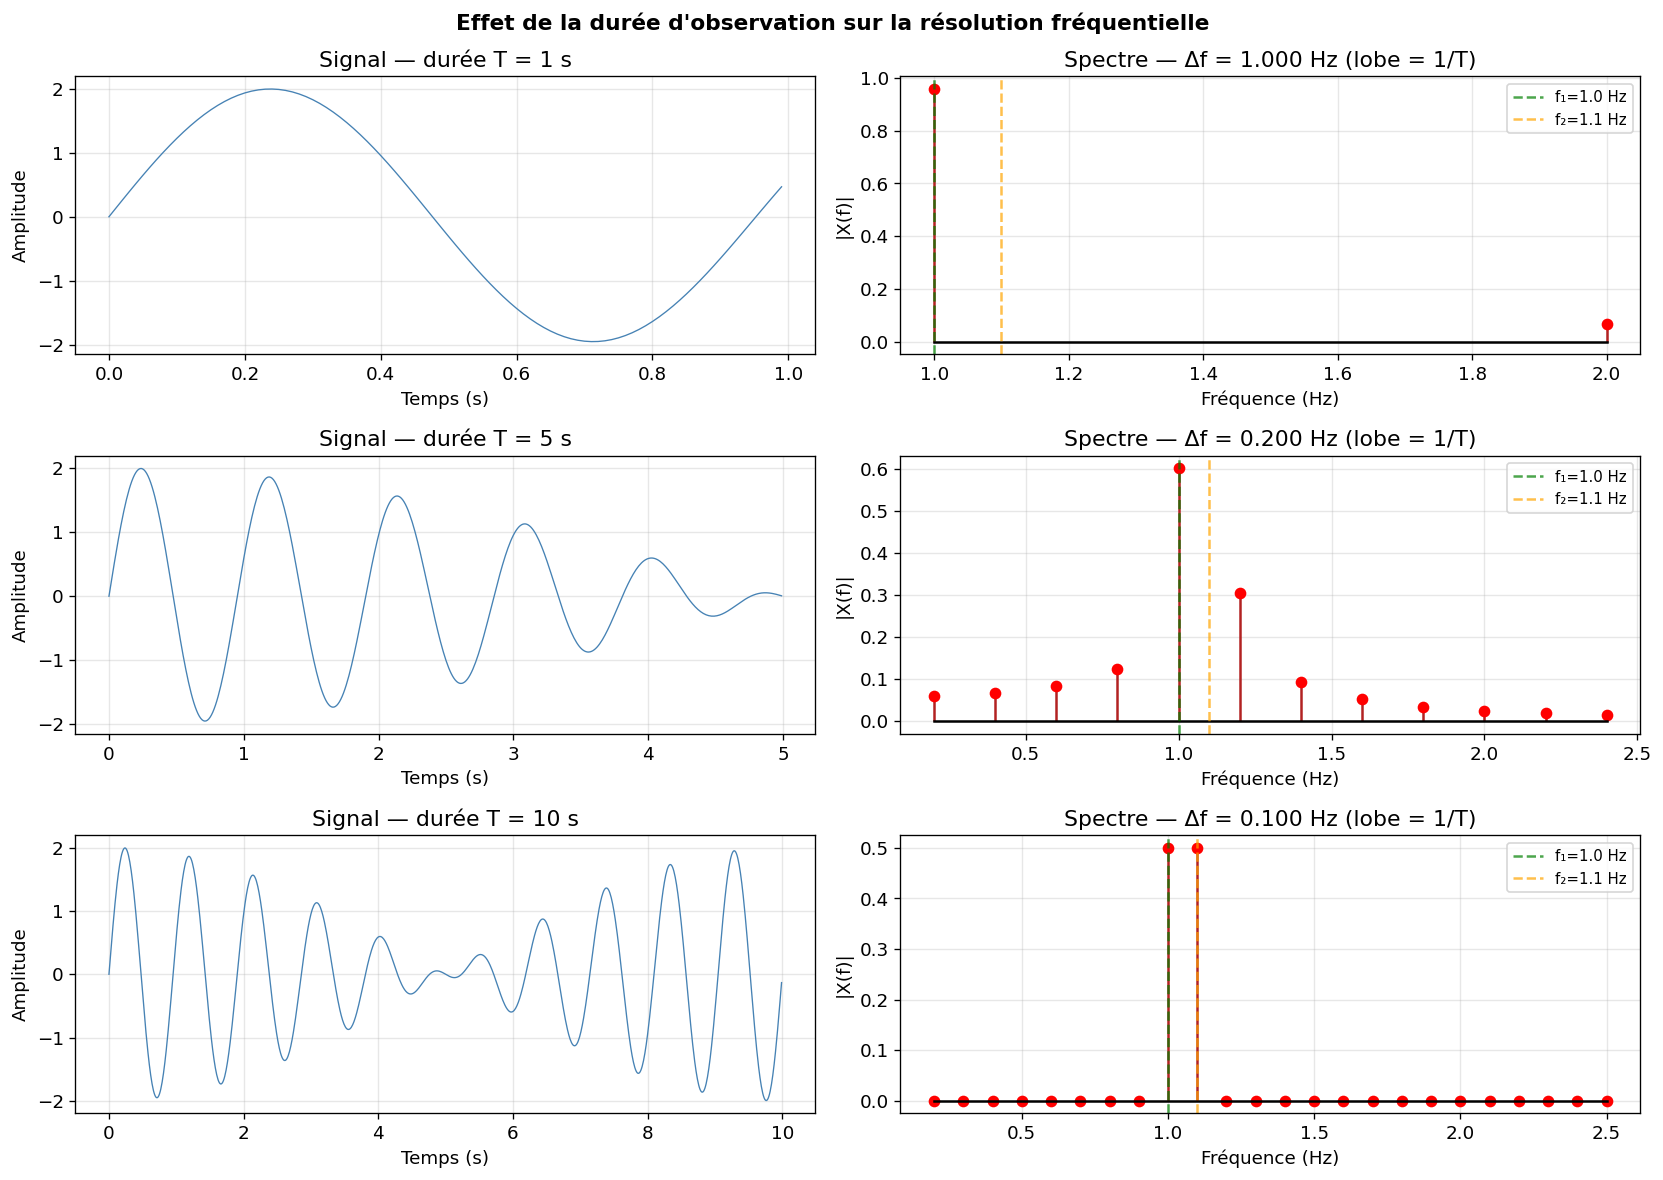

In [15]:
Fe = 100          # fréquence d'échantillonnage (Hz)
f1, f2 = 1.0, 1.1 # deux fréquences proches (Hz)

# On génère un signal long (30 s), puis on en prendra des morceaux
T_total = 30.0
t = np.arange(0, T_total, 1/Fe)
signal = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
durees = [1, 5, 10]  # secondes

for i, T in enumerate(durees):
    # Nombre d'échantillons correspondant à la durée T
    n = int(T * Fe)
    # Extraction du segment de signal de durée T
    seg = signal[:n]
    # Vecteur temps associé au segment
    t_seg = t[:n]

    # FFT
    X = np.fft.rfft(seg) / n  # Calcul de la FFT réelle, normalisée par le nombre d'échantillons
    freqs = np.fft.rfftfreq(n, 1/Fe)  # Calcul des fréquences associées à chaque bin/raie de la FFT (en Hz)
    module = np.abs(X) # Calcul du module du spectre (amplitude de chaque raie)

    # Signal temporel
    axes[i, 0].plot(t_seg, seg, color='steelblue', lw=0.8)
    axes[i, 0].set_title(f'Signal — durée T = {T} s')
    axes[i, 0].set_xlabel('Temps (s)')
    axes[i, 0].set_ylabel('Amplitude')

    
    # Spectre (zoom autour de 1 Hz)
    mask = (freqs >= 0.2) & (freqs <= 2.5)
    axes[i, 1].stem(freqs[mask], module[mask], linefmt='firebrick', markerfmt='ro', basefmt='k-')
    #axes[i, 1].plot(freqs[mask], module[mask], color='firebrick', lw=1.2)
    axes[i, 1].axvline(f1, color='green', ls='--', alpha=0.7, label=f'f₁={f1} Hz')
    axes[i, 1].axvline(f2, color='orange', ls='--', alpha=0.7, label=f'f₂={f2} Hz')
    axes[i, 1].set_title(f'Spectre — Δf = {1/T:.3f} Hz (lobe = 1/T)')
    axes[i, 1].set_xlabel('Fréquence (Hz)')
    axes[i, 1].set_ylabel('|X(f)|')
    axes[i, 1].legend(fontsize=9)

plt.suptitle('Effet de la durée d\'observation sur la résolution fréquentielle', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation :** avec T = 1 s, le lobe principal vaut 1 Hz — les deux fréquences (espacées de 0,1 Hz) sont confondues. Avec T = 10 s, le lobe vaut 0,1 Hz — elles sont juste séparées.

### 1.2 Le sinus cardinal : la tache laissée par une sinusoïde pure

Mathématiquement, une sinusoïde à $f_0$ observée pendant $T$ secondes laisse dans le spectre un **sinus cardinal** :

$$|X(f)| = T \cdot |\text{sinc}(T(f - f_0))|$$

Visualisons cette tache et comment elle évolue avec $T$ :

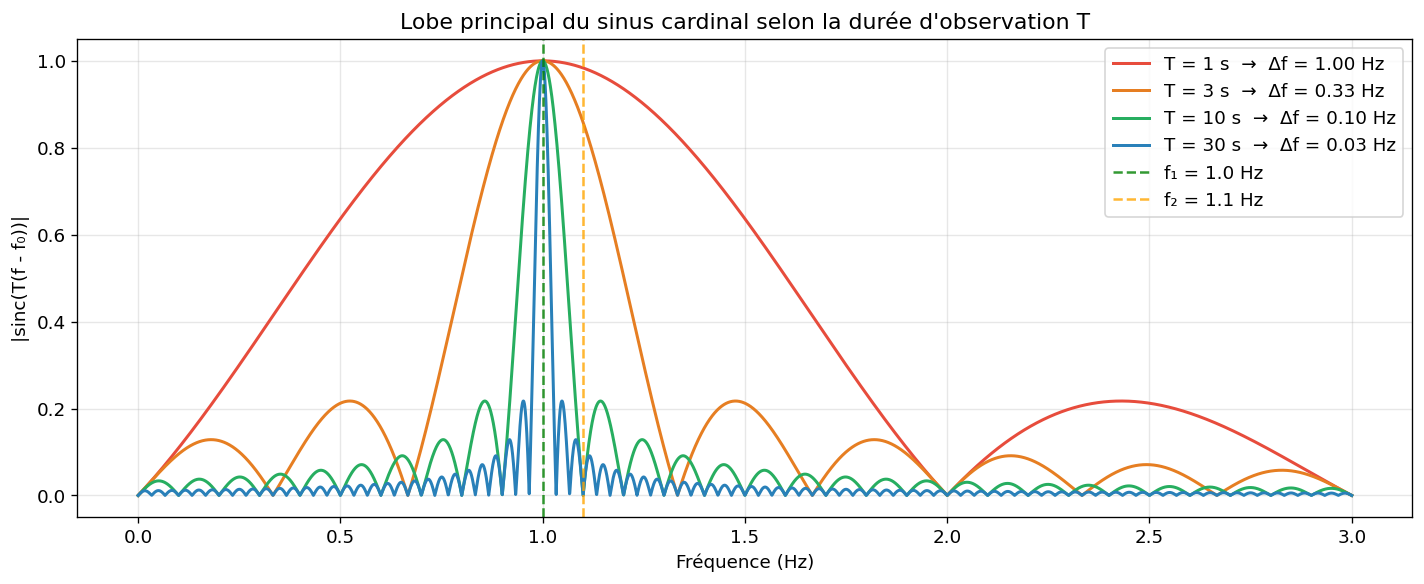

In [3]:
f0 = 1.0  # fréquence de la sinusoïde
f_axis = np.linspace(0, 3, 5000)

fig, ax = plt.subplots(figsize=(12, 5))

for T, color in zip([1, 3, 10, 30], ['#e74c3c', '#e67e22', '#27ae60', '#2980b9']):
    sinc_val = np.abs(np.sinc((f_axis - f0) * T))  # np.sinc inclut le π
    ax.plot(f_axis, sinc_val, label=f'T = {T} s  →  Δf = {1/T:.2f} Hz', color=color, lw=1.8)

ax.axvline(f1, color='green', ls='--', alpha=0.8, label=f'f₁ = {f1} Hz')
ax.axvline(f2, color='orange', ls='--', alpha=0.8, label=f'f₂ = {f2} Hz')
ax.set_xlabel('Fréquence (Hz)')
ax.set_ylabel('|sinc(T(f - f₀))|')
ax.set_title('Lobe principal du sinus cardinal selon la durée d\'observation T')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusion :** plus $T$ est grand, plus le lobe est étroit, plus la résolution est fine.

La règle est simple : **pour distinguer deux fréquences espacées de $\Delta f$, il faut $T \geq 1/\Delta f$.**

---
## Partie 2 — Le périodogramme et son problème de variance

### 2.1 Définition du périodogramme

Le périodogramme est l'estimateur naïf de la Densité Spectrale de Puissance (DSP) :

$$\hat{S}_{xx}(f) = \frac{1}{N} \left| \sum_{n=0}^{N-1} x[n]\, e^{-j2\pi fn/N} \right|^2$$

Créons un signal test : une sinusoïde à 5 Hz noyée dans du bruit blanc.

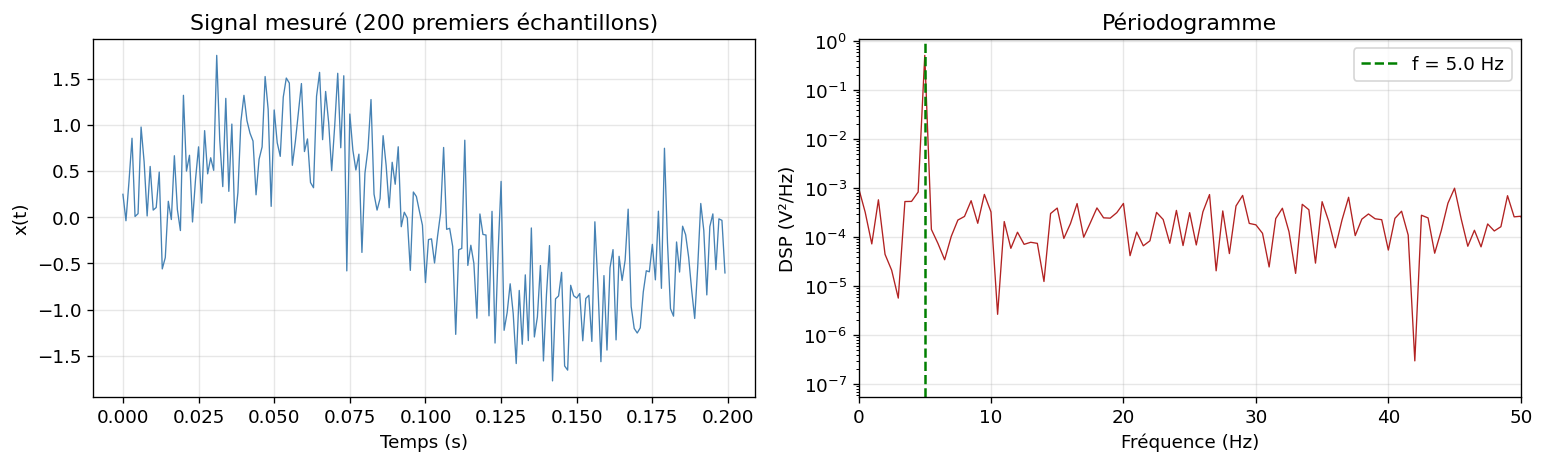

In [4]:
np.random.seed(42)
Fe = 1000          # Hz
T  = 2.0           # secondes
N  = int(T * Fe)
t  = np.arange(N) / Fe

f_signal = 5.0     # Hz
amplitude = 1.0
sigma_bruit = 0.5  # écart-type du bruit

signal_pur = amplitude * np.sin(2 * np.pi * f_signal * t)
bruit = sigma_bruit * np.random.randn(N)
x = signal_pur + bruit

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(t[:200], x[:200], lw=0.8, color='steelblue')
axes[0].set_title('Signal mesuré (200 premiers échantillons)')
axes[0].set_xlabel('Temps (s)')
axes[0].set_ylabel('x(t)')

# Périodogramme
freqs = np.fft.rfftfreq(N, 1/Fe)
P = (np.abs(np.fft.rfft(x))**2) / (N * Fe)

axes[1].semilogy(freqs, P, color='firebrick', lw=0.8)
axes[1].axvline(f_signal, color='green', ls='--', label=f'f = {f_signal} Hz')
axes[1].set_title('Périodogramme')
axes[1].set_xlabel('Fréquence (Hz)')
axes[1].set_ylabel('DSP (V²/Hz)')
axes[1].set_xlim(0, 50)
axes[1].legend()
plt.tight_layout()
plt.show()

### 2.2 Le problème : la variance ne diminue pas

Calculons le périodogramme pour **plusieurs réalisations différentes** du même signal (même fréquence, même amplitude, bruit différent). Si l'estimateur était bon, tous les spectres devraient être proches.

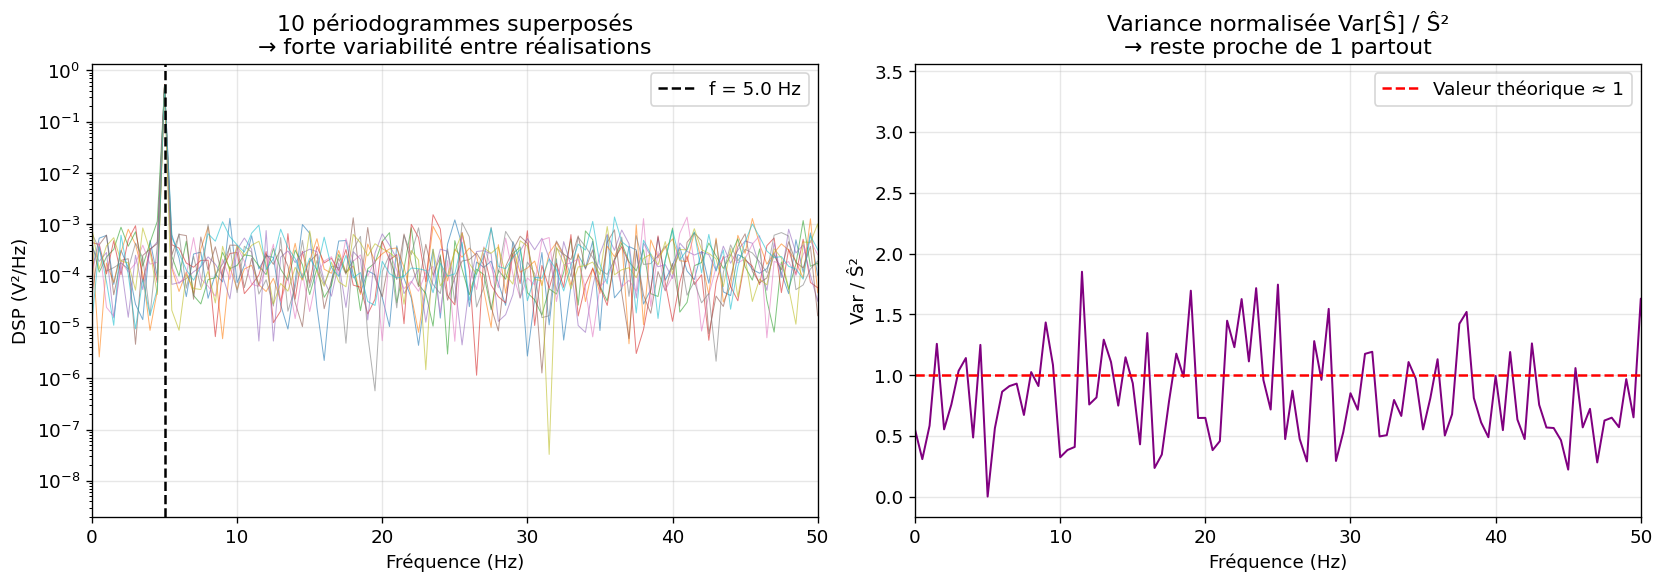

Variance normalisée moyenne : 0.820 (théorie : 1.0)


In [5]:
n_realisations = 10
periodogrammes = []

for seed in range(n_realisations):
    np.random.seed(seed)
    bruit_i = sigma_bruit * np.random.randn(N)
    x_i = signal_pur + bruit_i
    P_i = (np.abs(np.fft.rfft(x_i))**2) / (N * Fe)
    periodogrammes.append(P_i)

periodogrammes = np.array(periodogrammes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Toutes les réalisations superposées
for i, P_i in enumerate(periodogrammes):
    axes[0].semilogy(freqs, P_i, lw=0.6, alpha=0.6)
axes[0].axvline(f_signal, color='black', ls='--', lw=1.5, label=f'f = {f_signal} Hz')
axes[0].set_title(f'{n_realisations} périodogrammes superposés\n→ forte variabilité entre réalisations')
axes[0].set_xlabel('Fréquence (Hz)')
axes[0].set_ylabel('DSP (V²/Hz)')
axes[0].set_xlim(0, 50)
axes[0].legend()

# Variance fréquence par fréquence
variance = np.var(periodogrammes, axis=0)
moyenne  = np.mean(periodogrammes, axis=0)
axes[1].plot(freqs, variance / moyenne**2, color='purple', lw=1.2)
axes[1].axhline(1.0, color='red', ls='--', label='Valeur théorique ≈ 1')
axes[1].set_title('Variance normalisée Var[Ŝ] / Ŝ²\n→ reste proche de 1 partout')
axes[1].set_xlabel('Fréquence (Hz)')
axes[1].set_ylabel('Var / Ŝ²')
axes[1].set_xlim(0, 50)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Variance normalisée moyenne : {np.mean(variance / moyenne**2):.3f} (théorie : 1.0)")

**Résultat :** la variance normalisée $\text{Var}[\hat{S}] / \hat{S}^2 \approx 1$ partout, quelle que soit la fréquence. C'est la preuve que le périodogramme est un **estimateur inconsistant** : même avec plus de données, cette variance ne disparaît pas.

---
## Partie 3 — La méthode de Welch

### 3.1 Idée : découper et moyenner

Welch propose de :
1. **Découper** le signal en $K$ segments de longueur $L$ (avec recouvrement)
2. **Fenêtrer** chaque segment
3. **Calculer** le périodogramme de chaque segment
4. **Moyenner** les $K$ périodogrammes

Visualisons d'abord le découpage :

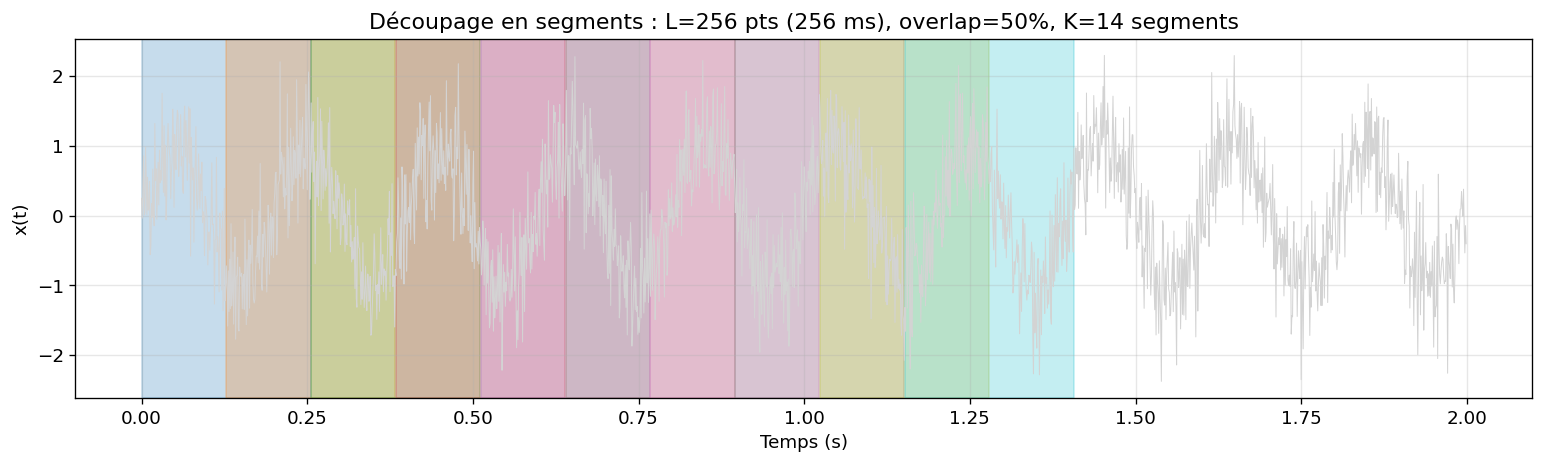

Signal : N=2000 pts, Fe=1000 Hz, durée=2.0 s
Segment : L=256 pts, durée=256.0 ms
Recouvrement : 128 pts (50%)
Nombre de segments : K=14
Résolution fréquentielle : Δf = Fe/L = 3.91 Hz


In [6]:
L = 256          # longueur d'un segment
overlap = L // 2 # recouvrement 50%
step = L - overlap

# Calcul du nombre de segments
starts = list(range(0, N - L + 1, step))
K = len(starts)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t, x, color='lightgray', lw=0.6, label='Signal complet')

colors = plt.cm.tab10(np.linspace(0, 1, min(K, 10)))
for i, start in enumerate(starts[:10]):  # on affiche les 10 premiers
    ax.axvspan(t[start], t[start + L - 1], alpha=0.25, color=colors[i])

ax.set_xlabel('Temps (s)')
ax.set_ylabel('x(t)')
ax.set_title(f'Découpage en segments : L={L} pts ({L/Fe*1000:.0f} ms), overlap=50%, K={K} segments')
plt.tight_layout()
plt.show()

print(f"Signal : N={N} pts, Fe={Fe} Hz, durée={T} s")
print(f"Segment : L={L} pts, durée={L/Fe*1000:.1f} ms")
print(f"Recouvrement : {overlap} pts (50%)")
print(f"Nombre de segments : K={K}")
print(f"Résolution fréquentielle : Δf = Fe/L = {Fe/L:.2f} Hz")

### 3.2 Le fenêtrage : pourquoi multiplier par une fenêtre ?

Tronquer un segment revient à multiplier par une **fenêtre rectangulaire**. Dans le domaine fréquentiel, cela crée des lobes secondaires importants (fuite spectrale). Une fenêtre douce (Hann, Hamming...) atténue ces artefacts.

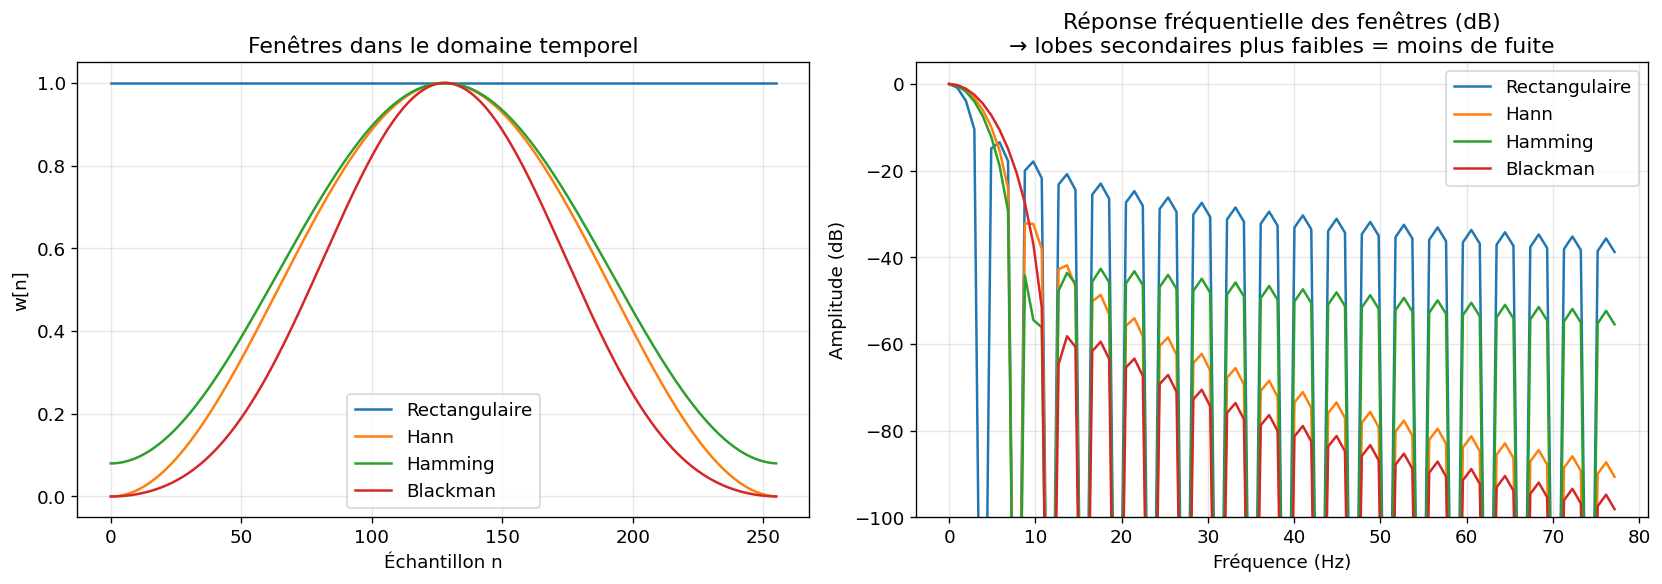

In [7]:
fenetres = {
    'Rectangulaire': np.ones(L),
    'Hann':     get_window('hann', L),
    'Hamming':  get_window('hamming', L),
    'Blackman': get_window('blackman', L),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_w = np.arange(L)

for nom, w in fenetres.items():
    # Fenêtre temporelle
    axes[0].plot(n_w, w, label=nom, lw=1.5)

    # Réponse fréquentielle (en dB)
    W = np.fft.rfft(w, n=4*L)
    W_dB = 20 * np.log10(np.abs(W) / np.abs(W).max() + 1e-10)
    f_w = np.fft.rfftfreq(4*L, 1/Fe)
    axes[1].plot(f_w[:80], W_dB[:80], label=nom, lw=1.5)

axes[0].set_title('Fenêtres dans le domaine temporel')
axes[0].set_xlabel('Échantillon n')
axes[0].set_ylabel('w[n]')
axes[0].legend()

axes[1].set_title('Réponse fréquentielle des fenêtres (dB)\n→ lobes secondaires plus faibles = moins de fuite')
axes[1].set_xlabel('Fréquence (Hz)')
axes[1].set_ylabel('Amplitude (dB)')
axes[1].set_ylim(-100, 5)
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.3 Calcul pas à pas de la méthode de Welch

Voici l'implémentation manuelle, pour bien voir chaque étape :

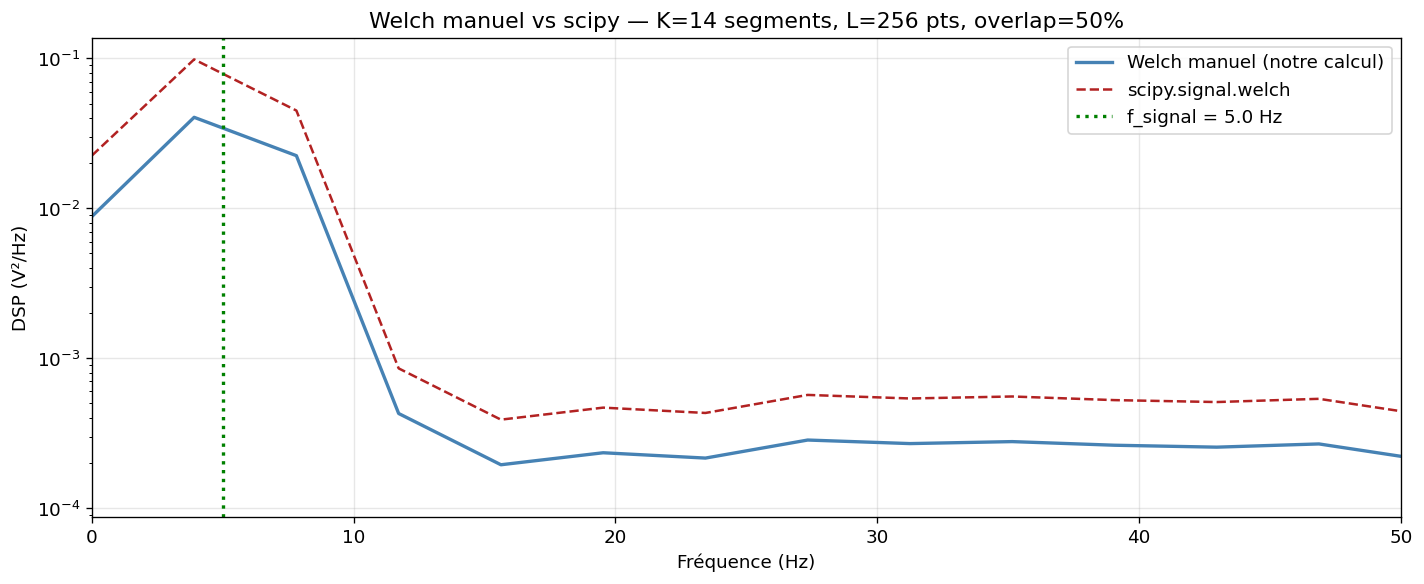

Les deux courbes sont identiques : notre implémentation est correcte.


In [8]:
# Paramètres
L = 256
overlap = L // 2
step = L - overlap
fenetre = get_window('hann', L)
U = np.sum(fenetre**2) / L  # facteur de normalisation de la fenêtre

# Découpage et calcul des périodogrammes individuels
starts = list(range(0, N - L + 1, step))
K = len(starts)
periodogrammes_segments = []

for start in starts:
    segment = x[start : start + L]          # 1. Extraction du segment
    segment_fen = segment * fenetre          # 2. Fenêtrage
    X_k = np.fft.rfft(segment_fen)          # 3. FFT
    P_k = np.abs(X_k)**2 / (L * U * Fe)    # 4. Périodogramme normalisé
    periodogrammes_segments.append(P_k)

periodogrammes_segments = np.array(periodogrammes_segments)

# 5. Moyenne
S_welch_manuel = np.mean(periodogrammes_segments, axis=0)
freqs_welch = np.fft.rfftfreq(L, 1/Fe)

# Vérification avec scipy.signal.welch
f_scipy, S_scipy = welch(x, fs=Fe, window='hann', nperseg=L, noverlap=overlap)

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(freqs_welch, S_welch_manuel, label='Welch manuel (notre calcul)', lw=2, color='steelblue')
ax.semilogy(f_scipy, S_scipy, label='scipy.signal.welch', lw=1.5, ls='--', color='firebrick')
ax.axvline(f_signal, color='green', ls=':', lw=2, label=f'f_signal = {f_signal} Hz')
ax.set_xlabel('Fréquence (Hz)')
ax.set_ylabel('DSP (V²/Hz)')
ax.set_title(f'Welch manuel vs scipy — K={K} segments, L={L} pts, overlap=50%')
ax.set_xlim(0, 50)
ax.legend()
plt.tight_layout()
plt.show()
print("Les deux courbes sont identiques : notre implémentation est correcte.")

### 3.4 Welch vs périodogramme : comparaison finale

On compare maintenant les deux estimateurs sur **plusieurs réalisations** pour visualiser la réduction de variance :

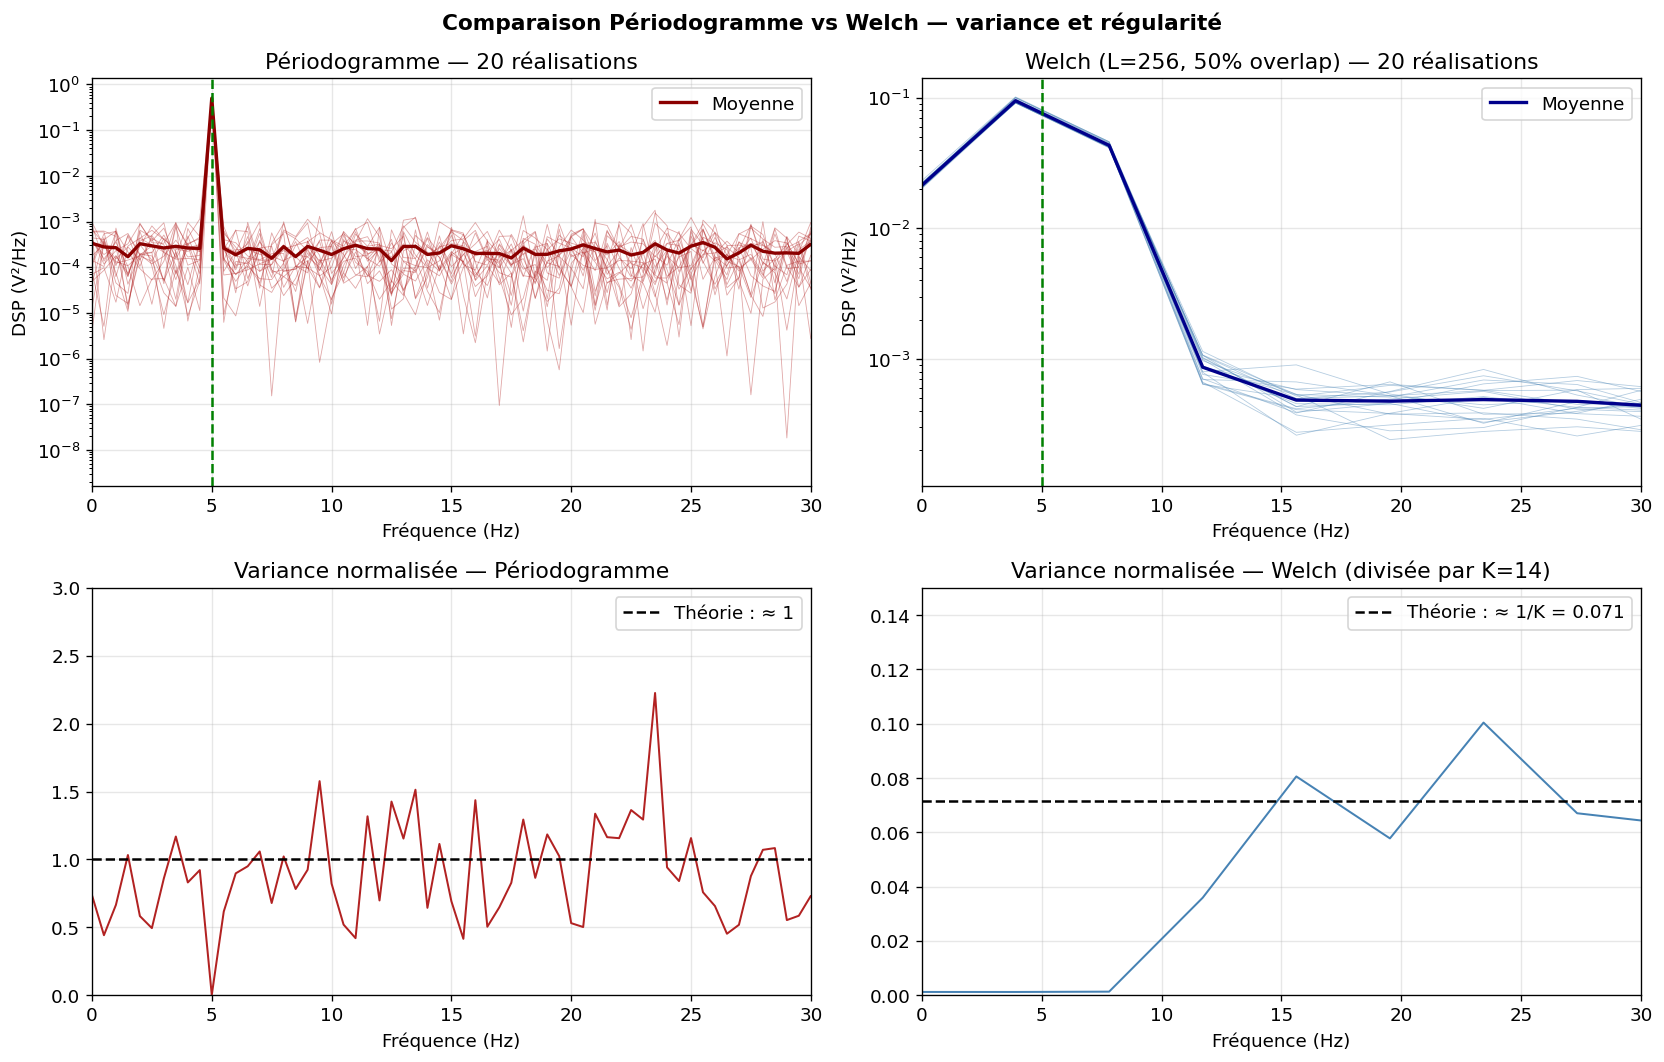

Réduction de variance moyenne : 0.902 → 0.065
Facteur de réduction observé : 14.0x  (théorie : K=14x)


In [9]:
n_real = 20
perio_all  = []
welch_all  = []

for seed in range(n_real):
    np.random.seed(seed)
    x_i = signal_pur + sigma_bruit * np.random.randn(N)

    # Périodogramme simple
    P_i = (np.abs(np.fft.rfft(x_i))**2) / (N * Fe)
    perio_all.append(P_i)

    # Welch
    _, S_i = welch(x_i, fs=Fe, window='hann', nperseg=L, noverlap=overlap)
    welch_all.append(S_i)

perio_all = np.array(perio_all)
welch_all = np.array(welch_all)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- Périodogramme ---
for P_i in perio_all:
    axes[0, 0].semilogy(freqs, P_i, lw=0.5, alpha=0.4, color='firebrick')
axes[0, 0].semilogy(freqs, np.mean(perio_all, axis=0), lw=2, color='darkred', label='Moyenne')
axes[0, 0].axvline(f_signal, color='green', ls='--')
axes[0, 0].set_title(f'Périodogramme — {n_real} réalisations')
axes[0, 0].set_xlim(0, 30); axes[0, 0].legend()
axes[0, 0].set_xlabel('Fréquence (Hz)'); axes[0, 0].set_ylabel('DSP (V²/Hz)')

# --- Welch ---
for S_i in welch_all:
    axes[0, 1].semilogy(f_scipy, S_i, lw=0.5, alpha=0.4, color='steelblue')
axes[0, 1].semilogy(f_scipy, np.mean(welch_all, axis=0), lw=2, color='darkblue', label='Moyenne')
axes[0, 1].axvline(f_signal, color='green', ls='--')
axes[0, 1].set_title(f'Welch (L={L}, 50% overlap) — {n_real} réalisations')
axes[0, 1].set_xlim(0, 30); axes[0, 1].legend()
axes[0, 1].set_xlabel('Fréquence (Hz)'); axes[0, 1].set_ylabel('DSP (V²/Hz)')

# --- Variance normalisée ---
var_perio = np.var(perio_all, axis=0) / np.mean(perio_all, axis=0)**2
var_welch = np.var(welch_all, axis=0) / np.mean(welch_all, axis=0)**2

axes[1, 0].plot(freqs, var_perio, color='firebrick', lw=1.2)
axes[1, 0].axhline(1.0, color='black', ls='--', label='Théorie : ≈ 1')
axes[1, 0].set_title('Variance normalisée — Périodogramme')
axes[1, 0].set_xlim(0, 30); axes[1, 0].set_ylim(0, 3)
axes[1, 0].set_xlabel('Fréquence (Hz)'); axes[1, 0].legend()

axes[1, 1].plot(f_scipy, var_welch, color='steelblue', lw=1.2)
axes[1, 1].axhline(1/K, color='black', ls='--', label=f'Théorie : ≈ 1/K = {1/K:.3f}')
axes[1, 1].set_title(f'Variance normalisée — Welch (divisée par K={K})')
axes[1, 1].set_xlim(0, 30); axes[1, 1].set_ylim(0, 0.15)
axes[1, 1].set_xlabel('Fréquence (Hz)'); axes[1, 1].legend()

plt.suptitle('Comparaison Périodogramme vs Welch — variance et régularité', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Réduction de variance moyenne : {np.mean(var_perio):.3f} → {np.mean(var_welch):.3f}")
print(f"Facteur de réduction observé : {np.mean(var_perio)/np.mean(var_welch):.1f}x  (théorie : K={K}x)")

### 3.5 Le compromis résolution–variance

Testons plusieurs tailles de segments $L$ pour visualiser le compromis :

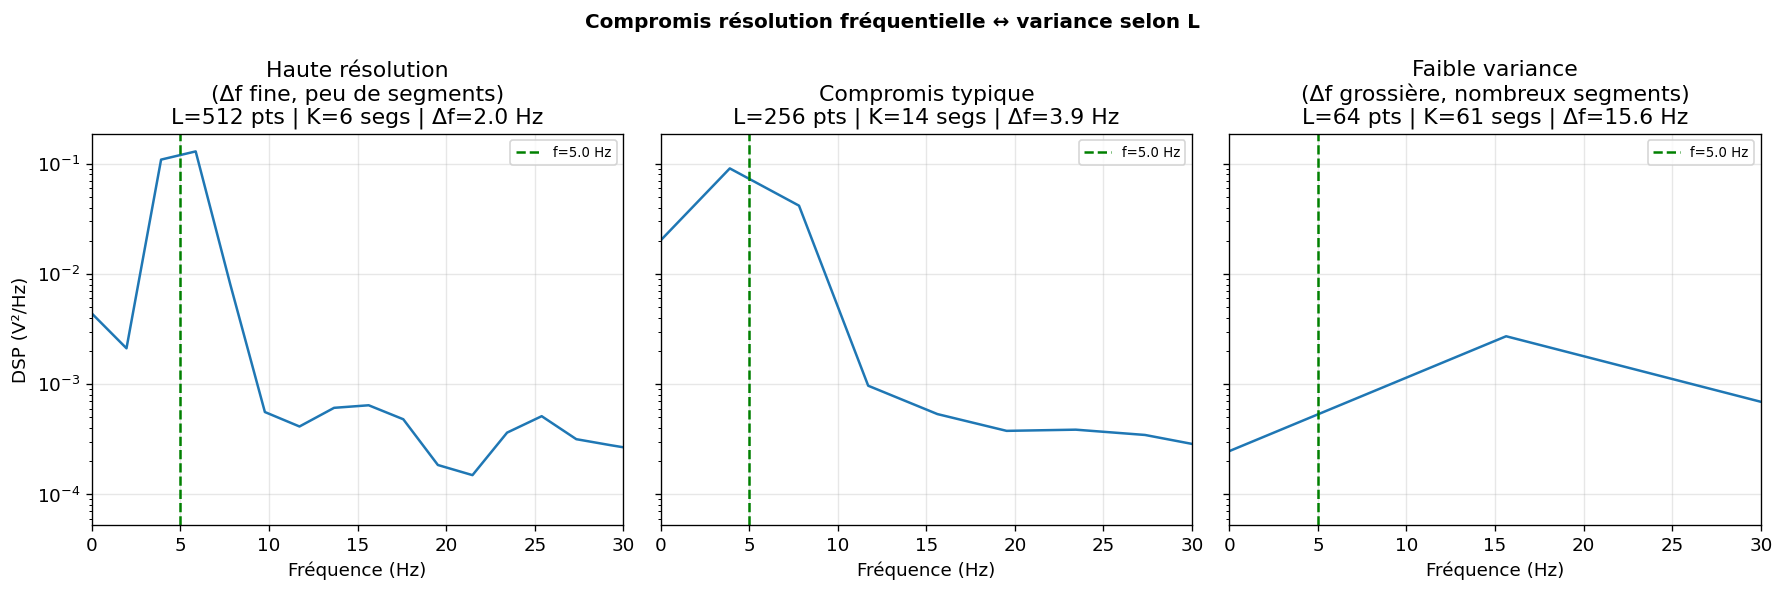

In [10]:
np.random.seed(0)
x_test = signal_pur + sigma_bruit * np.random.randn(N)

configs = [
    (512,  256,  'Haute résolution\n(Δf fine, peu de segments)'),
    (256,  128,  'Compromis typique'),
    (64,   32,   'Faible variance\n(Δf grossière, nombreux segments)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (L_i, ov_i, titre) in zip(axes, configs):
    f_i, S_i = welch(x_test, fs=Fe, window='hann', nperseg=L_i, noverlap=ov_i)
    n_seg = len(list(range(0, N - L_i + 1, L_i - ov_i)))

    ax.semilogy(f_i, S_i, lw=1.5)
    ax.axvline(f_signal, color='green', ls='--', label=f'f={f_signal} Hz')
    ax.set_title(f'{titre}\nL={L_i} pts | K={n_seg} segs | Δf={Fe/L_i:.1f} Hz')
    ax.set_xlabel('Fréquence (Hz)')
    ax.set_xlim(0, 30)
    ax.legend(fontsize=8)

axes[0].set_ylabel('DSP (V²/Hz)')
plt.suptitle('Compromis résolution fréquentielle ↔ variance selon L', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Bilan

| | Périodogramme simple | Méthode de Welch |
|---|---|---|
| **Résolution fréquentielle** | $\Delta f = F_e / N$ (fine) | $\Delta f = F_e / L$ (moins fine) |
| **Variance** | $\approx S^2(f)$ — **ne diminue pas** | $\approx S^2(f) / K$ — **divisée par K** |
| **Consistance** | Non | Oui (si $K \to \infty$) |
| **Fuite spectrale** | Forte (fenêtre rectangulaire) | Atténuée (fenêtre douce) |

**Le choix de $L$** est le seul vrai levier de l'ingénieur : il détermine simultanément la résolution fréquentielle $\Delta f = F_e/L$ et, via $K$, la réduction de variance. Recouvrement 50 % + fenêtre de Hann est le réglage par défaut universel.

### Références
- Welch, P.D. (1967). *IEEE Transactions on Audio and Electroacoustics*, 15(2), 70–73.
- [MATLAB `pwelch`](https://fr.mathworks.com/help/signal/ref/pwelch.html)
- [scipy.signal.welch](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html)